# Batch analysis of cosmic rays using Drift Tubes detectors

### MAPD-b Project - 02/09/2025
### Group 12

- Cafagno Samuele - 2159164
- Cavallin Jonathan - 2159285
- Di Lucia Sofia - 2149752

# Cluster Definition

In [1]:
import dask
from dask.distributed import Client
from dask.distributed import SSHCluster
from dask.distributed import LocalCluster 
from dask.delayed import delayed
import dask.dataframe as dd
import dask.array as da
import dask.bag as d
import graphviz
import pandas as pd
import numpy as np
import itertools
from time import time
import time
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import logging
from dask.distributed import wait

warnings.filterwarnings("ignore")

For this project we used a distributed cluster of Virtual Machines hosted on the CloudVeneto infrastracture. 

### Virtual Machine's Specs:
- **Scheduler + Worker 0** (10.67.22.48): RAM - 16GB, 8 VCPU, Disk - 25GB
- **Worker 1** (10.67.22.229): RAM - 8GB, 4 VCPU, Disk - 25GB
- **Worker 2** (10.67.22.45): RAM - 8GB, 4 VCPU, Disk - 25GB

In [2]:
n_workers = 2 # number of workers per host
nthreads  = 2 # number of threads per worker

cluster = SSHCluster(
    ["10.67.22.48", "10.67.22.48", "10.67.22.229", "10.67.22.45"],
    worker_options={"nthreads": nthreads, "n_workers": n_workers},
    scheduler_options={"port":0, "dashboard_address": ":40973"},
    connect_options={
    "known_hosts": None,
    "client_keys": "cluster_key"})

#client = Client(cluster, timeout='60s')
client = Client(cluster,'dask-scheduler:8787')


2025-08-30 15:53:51,072 - distributed.deploy.ssh - INFO - 2025-08-30 15:53:51,072 - distributed.scheduler - INFO - State start
2025-08-30 15:53:51,076 - distributed.deploy.ssh - INFO - 2025-08-30 15:53:51,075 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-k0ugwgdm', purging
2025-08-30 15:53:51,079 - distributed.deploy.ssh - INFO - 2025-08-30 15:53:51,078 - distributed.scheduler - INFO -   Scheduler at:   tcp://10.67.22.48:39831
2025-08-30 15:53:52,178 - distributed.deploy.ssh - INFO - 2025-08-30 15:53:52,177 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.48:35251'
2025-08-30 15:53:52,181 - distributed.deploy.ssh - INFO - 2025-08-30 15:53:52,181 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.48:37203'
2025-08-30 15:53:52,398 - distributed.deploy.ssh - INFO - 2025-08-30 15:53:52,401 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.45:38295'
2025-08-30 15:53:52,400 - di

In [3]:
client

<Client: 'tcp://10.67.22.48:39831' processes=4 threads=8, memory=15.56 GiB>

In [4]:
print(client.dashboard_link)
print(client.scheduler_info()["address"])
print(client.scheduler_info()["services"])

http://10.67.22.48:40973/status
tcp://10.67.22.48:39831
{'dashboard': 40973}


In [5]:
client.scheduler_info()['workers'].keys()

dict_keys(['tcp://10.67.22.229:32779', 'tcp://10.67.22.229:40585', 'tcp://10.67.22.45:33201', 'tcp://10.67.22.45:38919', 'tcp://10.67.22.48:33865'])

# Data import and Preprocessing

The raw data collected by the DAQ detector needs to be unpacked and processed as needed for the project. Here we define the functions to handle these operations. 

In particoular, **read_file()** and **bites_converter()** unpack the binary data relevant to the project (with HEAD==2) from the input file and return a dask dataframe. 
**first_processing()** groups the data based on the ORBITS time information, and selects only data with a single scintillator event per orbit (in order to be able to identify a unique reference value to estimate the drift time of electrons in the chambers). Furthermore, here we assign to each data the corresponding chamber based on HEAD and CHANNEL information; we then apply the time-offset corrections for the scintillator hits and convert the TDC data to time in nano-seconds. \
**compute_coordinates()** defines spatial coordinates for the chamber hits converting the time informations of each event. We can reconstruct the X coordinate of each hit using the drift time previously computed up to a left/right ambiguity, so we define two possible Xs (XLEFT and XRIGHT) for each hit. 

To apply each function to the whole dataset considered we used he DASK function **map_partition()** that applies (map) the same function to every partition of the dask dataframe.

In [6]:
## >> xx selects rotates bits to the right by xx places
@dask.delayed
def bites_converter(block): 
    # organize in numpy arrays of 64 bits
    byte_array = np.frombuffer(block, dtype=np.uint64)
    
    # bit masking
    head = (byte_array >> 61) & 0x7         # select bits 61–63 (3 bits)
    fpga = (byte_array >> 58) & 0x7         # select bits 58–60 (3 bits)
    chan = (byte_array >> 49) & 0x1FF       # select bits 49–57 (9 bits)
    orbit = (byte_array >> 17) & 0xFFFFFFFF  # select bits 17–48 (32 bits)
    bx = (byte_array >> 5) & 0xFFF        # select bits 5–16 (12 bits)
    tdc = (byte_array >> 0) & 0x1F         # select bits 0–4 (5 bits)
    
    # we are only interested in data with head==2 
    df = pd.DataFrame(
    {"FPGA": fpga[head==2],
    "CHAN": chan[head==2],
    "ORBIT": orbit[head==2],
    "BX": bx[head==2],
    "TDC": tdc[head==2]} )
    
    return(df)

In [7]:
def read_file(file):

    client_kwargs={
        "endpoint_url": "https://cloud-areapd.pd.infn.it:5210", "verify": False}

    # small is a small bytes object from the start of the first file (to infer format), block is a list of Dask delayed objects, representing chunks of bytes from a file
    small, blocks = dask.bytes.read_bytes(
            file,
            key="32b22133696b4aad9a2872435d392277",
            secret="d2111717321d4f7dbd6755b98e95e713",
            client_kwargs=client_kwargs)  
    
    dfs = [dask.delayed(bites_converter)(block[0]) for block in blocks] # apply converter to each block lazily (each block object is a tuple, so i select [0])
    # converts a list of Dask delayed objects (chunks of a DataFrame) into a unique Dask DataFrame
    ddf = dd.from_delayed(dfs)
    return(ddf)

In [8]:
# This fuction:
# - filters events with a single scintillator hit per orbit (in order to be able to identify a unique t_0)
# - assigns the chamber number to each event
# - consider only events with more than 4 and less than num_hits chamber hits per orbit (4 are usually needed to pass the 4 detector layers, if less it is very likely noise) 
# - calculates relative time between the chamber hits and the scintillator hits to determine the drift time
def first_processing(df,num_hits):
    
    # select scintillator hits
    scintillator = df[(df["FPGA"]==1) & (df["CHAN"]==128)].copy()
    scintillator = scintillator[["ORBIT", "BX", "TDC"]]
    scintillator["t_0"] = 25*(scintillator["ORBIT"]*3564 + scintillator["BX"] + scintillator["TDC"]/30)
    
    # count scintillator hits per ORBIT
    scint_counts = scintillator.groupby("ORBIT").size().to_frame("scint_hits").reset_index()
    # keep only ORBITs with a single scintillator hit
    valid_orbits = scint_counts[scint_counts["scint_hits"] == 1]["ORBIT"]
    
     
    df = df[df["CHAN"]<=127] # remove info about the scintillator

    # assign chamber number
    df = df.assign(CHAMBER = -1)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 0) & (df["CHAN"] <= 63), 0)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 0) & (df["CHAN"] > 63), 1)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 1) & (df["CHAN"] <= 63), 2)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 1) & (df["CHAN"] > 63), 3)

    # scintilattor time offset correction, per chamber
    df = df.assign(time_offset = 0.0)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 0, 95.0-1.1)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 1, 95.0+6.4)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 2, 95.0+0.5)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 3, 95.0-2.6)
    
    df["T_HIT"] = 25*(df["ORBIT"]*3564 + df["BX"] + df["TDC"]/30)
    
    # filter scintillator hits and main df: keep only events with 1 scintillator hit per ORBIT
    scintillator = scintillator[scintillator["ORBIT"].isin(valid_orbits)]
    df = df[df["ORBIT"].isin(valid_orbits)]

    # consider only events with ≤ num_hits chamber hits per ORBIT (avoid overcrowded events)
    chamber_counts = df.groupby("ORBIT").size().to_frame("hits_count").reset_index()
    valid_orbits = chamber_counts[(chamber_counts["hits_count"]<=num_hits)&(chamber_counts["hits_count"]>=4)][["ORBIT"]]
    df = df[df["ORBIT"].isin(valid_orbits["ORBIT"])]

    t0_df = scintillator[["ORBIT", "t_0"]]  # only 1 scint hit per ORBIT guaranteed here
   
    # merge t₀_df with df
    df = df.merge(t0_df, on="ORBIT", how="left") 
    
    # calculate relative chamber hit times
    df["T_REL"] = df["T_HIT"] - (df["t_0"]-df["time_offset"])
    
    return(df)    

In [9]:
# compute x and z coordinates of the chamber hits (left and right ambiguity for the x coordinate in each hit)
def compute_coordinates(df):
    
    df["x"]=-7.5*42.0 # center of the first cell to the left in each chamber
    df["z"]=0

    # assign the z-position of the center of each chamber w.r.t. to the floor
    df["z"]=df["z"].mask(df["CHAMBER"]==0,219.8)
    df["z"]=df["z"].mask(df["CHAMBER"]==1,977.3)
    df["z"]=df["z"].mask(df["CHAMBER"]==2,1035.6)
    df["z"]=df["z"].mask(df["CHAMBER"]==3,1819.8)

    df["CHAN_LOCAL"] = df["CHAN"]
    df["CHAN_LOCAL"] = df["CHAN_LOCAL"].mask(df["CHAMBER"].isin([1,3]), df["CHAN"]- 64) 

    layer_map = [3, 1, 2, 0]
    df["layer"] = df["CHAN_LOCAL"]%4
    df["layer"] = df["layer"].map({i: layer_map[i] for i in range(4)})

    df["x"]= df["x"] + df["CHAN_LOCAL"]// 2 * 21.
    df["z"]= df["z"] - 26.0 + (df["layer"]+0.5)*13.

    df["drift"]= df["T_REL"]*53.8*0.001
    df = df[(df["drift"]>=0)&(df["drift"]<=21.)] # drift can be at most half of the cell, discard other events (meaningless)
    
    df["X_RIGHT"]= df["x"]+df["drift"] 
    df["X_LEFT"]= df["x"]-df["drift"]

    return(df)

In [10]:
df = read_file("s3://project-bkp/data_00000*") # use all files

In [11]:
df.npartitions

10

In [12]:
df.map_partitions(len).compute() # number of rows in each partition

0    1239940
0    1243176
0    1243816
0    1243252
0    1242676
0    1242348
0    1243244
0    1241716
0    1243108
0    1244404
dtype: int64

In [13]:
df = df.map_partitions(first_processing,num_hits=25)

The **.visualize()** option allows us to show the graphs of how the data processing is split between the multiple partitions and with **.compute()** and **.persist()** we actually perform the operations and visualize the dataframe. 

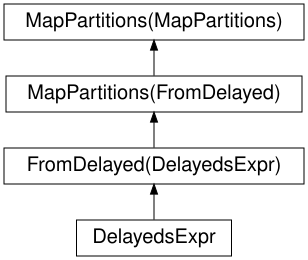

In [14]:
new_df = df.map_partitions(compute_coordinates)
new_df.visualize(filename="graph.png")

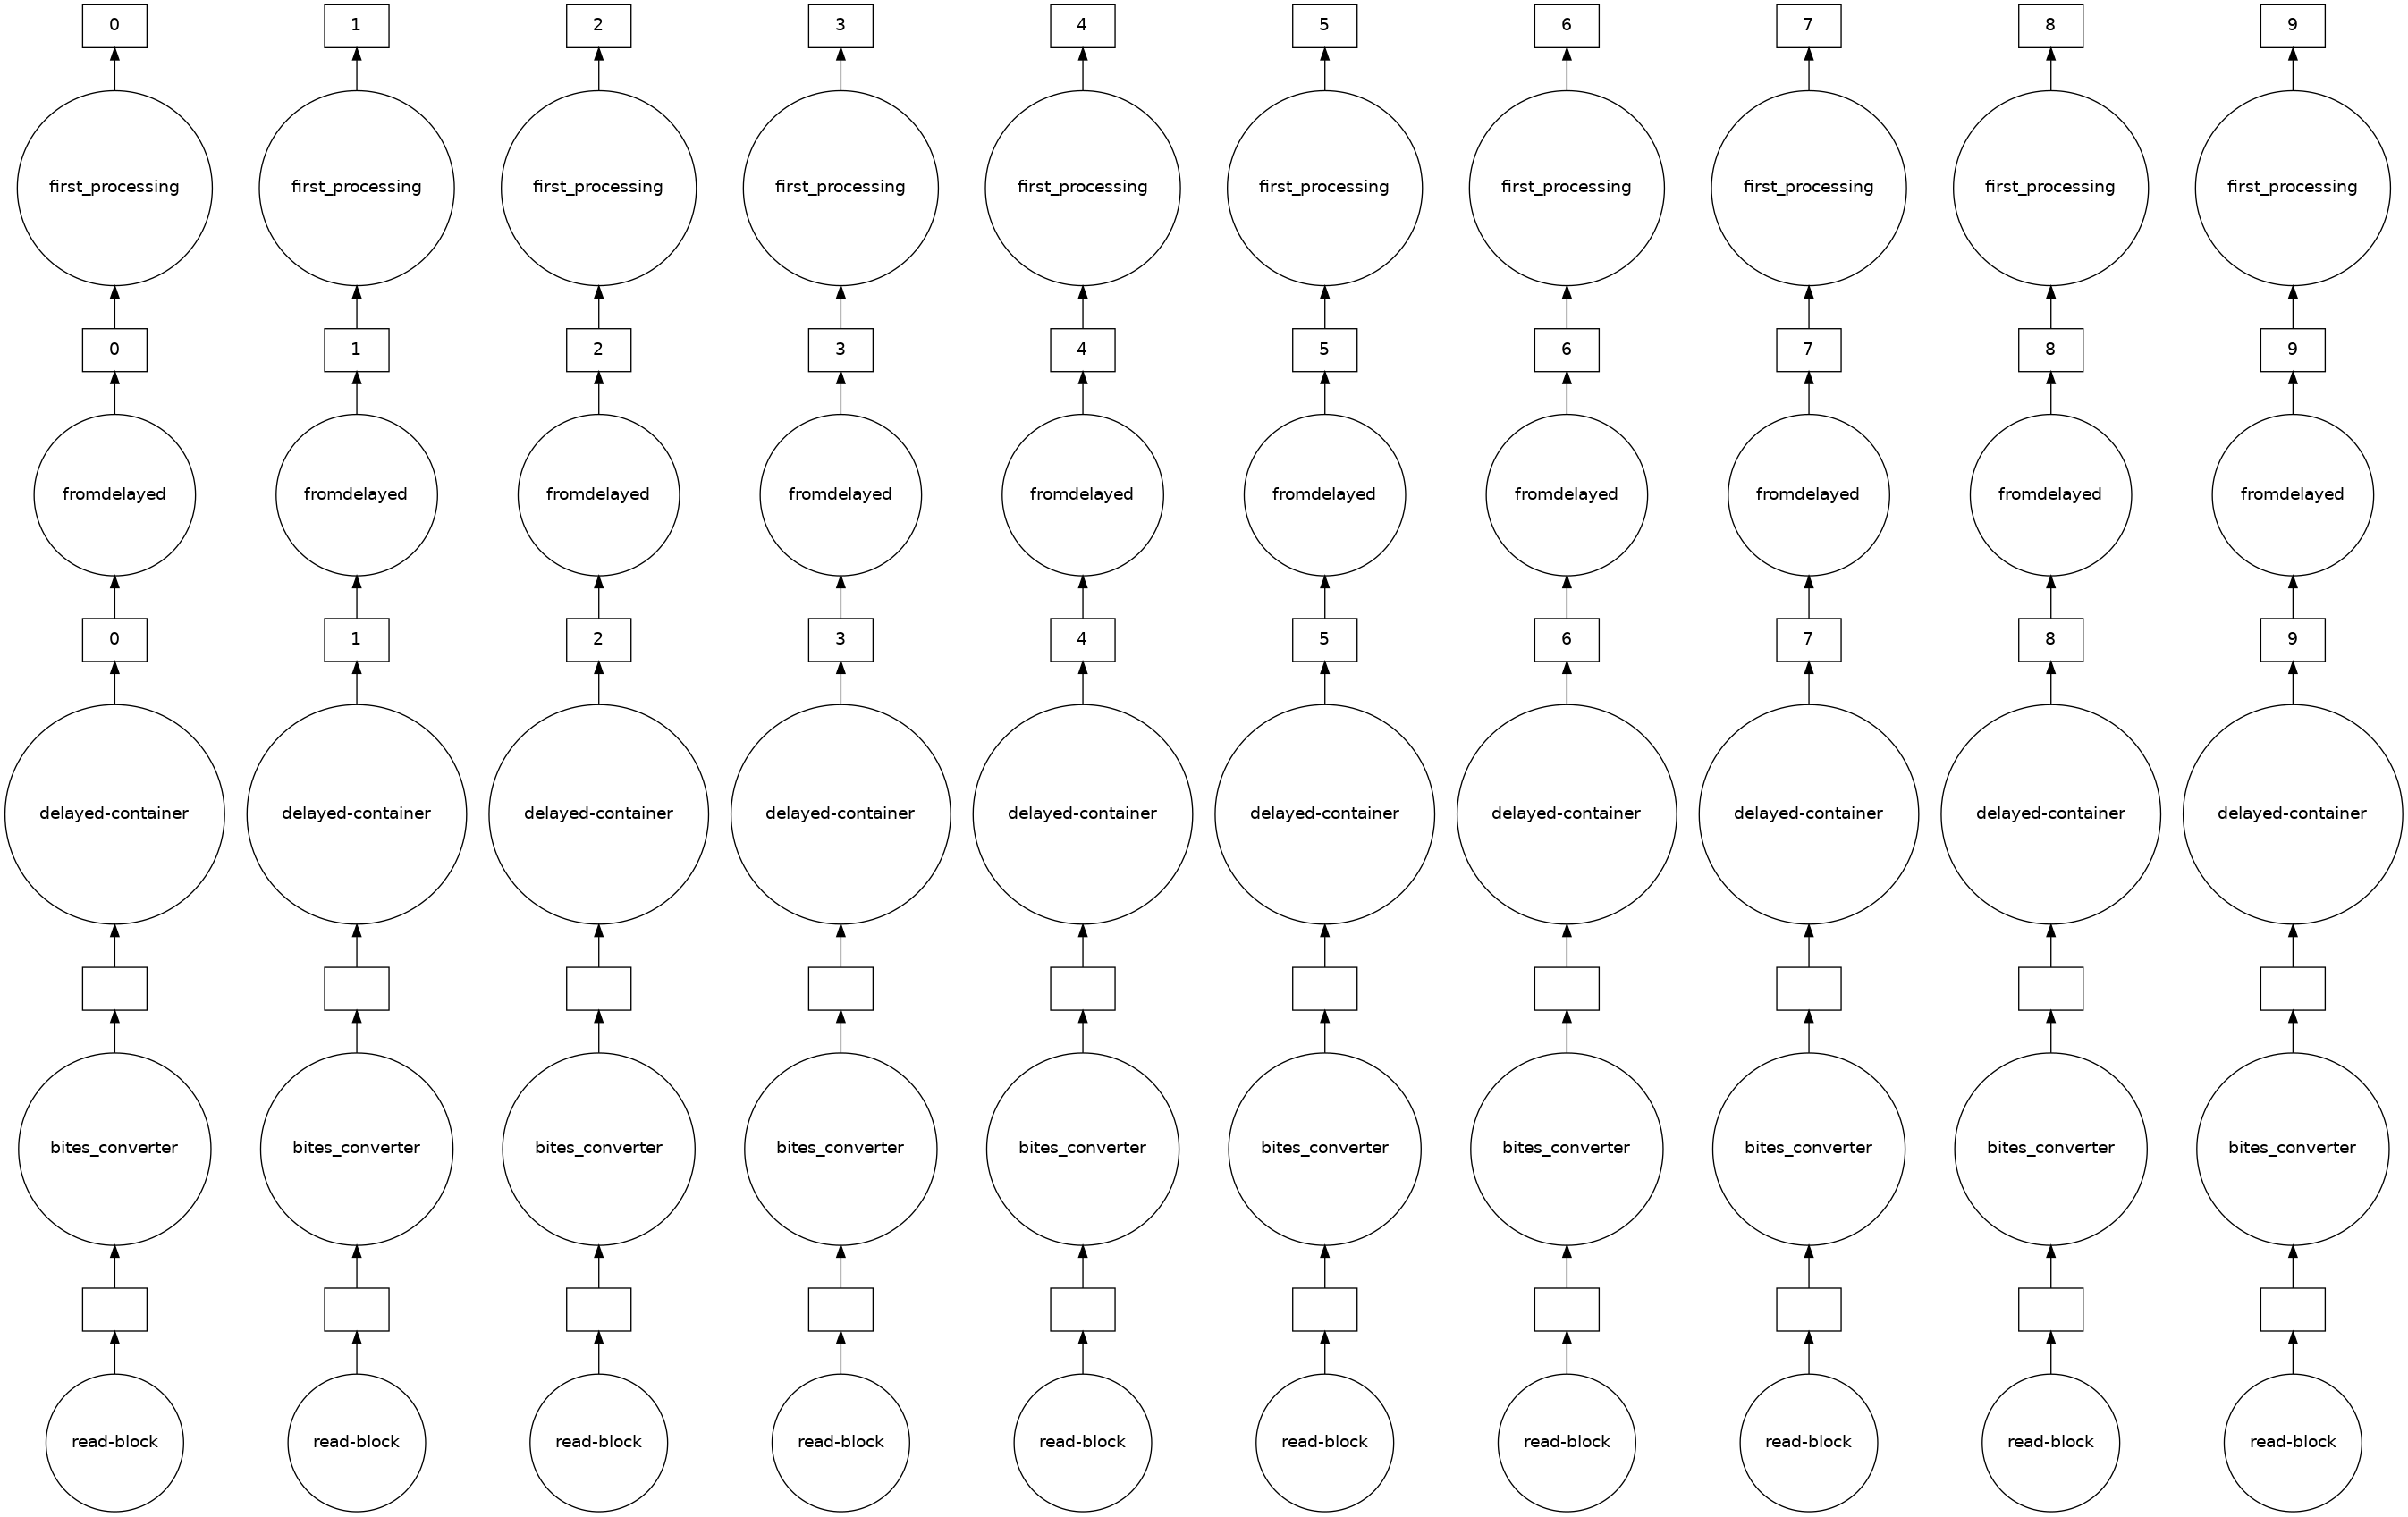

In [15]:
ddf = new_df.to_delayed()
ddf[0].visualize(filename="graph_chunk0.png")


In [16]:
start = time.time()

persisted = new_df.persist()
wait(persisted)   ### waits for the computation to finish to give back the actual time of computation 

end = time.time()
print(f"Persist took {end - start:.2f} seconds")

Persist took 1.94 seconds


In [17]:
%%time
new_df.compute()


CPU times: user 20.6 ms, sys: 8.03 ms, total: 28.7 ms
Wall time: 2 s


,FPGA,CHAN,ORBIT,BX,TDC,CHAMBER,time_offset,T_HIT,t_0,T_REL,x,z,CHAN_LOCAL,layer,drift,X_RIGHT,X_LEFT
0,1,91,1118948,878,27,3,92.4,9.969829e+10,9.969829e+10,34.066666,-42.0,1800.3,27,0,1.832787,-40.167213,-43.832787
1,0,107,1118948,882,8,1,101.4,9.969829e+10,9.969829e+10,127.233337,126.0,957.8,43,0,6.845154,132.845154,119.154846
2,1,47,1118948,881,18,2,95.5,9.969829e+10,9.969829e+10,104.666672,168.0,1016.1,47,0,5.631067,173.631067,162.368933
3,1,88,1118948,884,12,3,92.4,9.969829e+10,9.969829e+10,171.566666,-63.0,1839.3,24,3,9.230287,-53.769713,-72.230287
4,1,44,1118948,881,14,2,95.5,9.969829e+10,9.969829e+10,101.333344,147.0,1055.1,44,3,5.451734,152.451734,141.548266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7659,0,108,48580108,3047,25,1,101.4,4.328488e+12,4.328488e+12,282.233398,147.0,996.8,44,3,15.184157,162.184157,131.815843
7660,0,105,48580108,3048,22,1,101.4,4.328488e+12,4.328488e+12,304.733398,105.0,970.8,41,1,16.394657,121.394657,88.605343
7661,1,40,48580108,3046,13,2,95.5,4.328488e+12,4.328488e+12,241.333008,105.0,1055.1,40,3,12.983716,117.983716,92.016284
7662,1,38,48580108,3047,1,2,95.5,4.328488e+12,4.328488e+12,256.333008,84.0,1042.1,38,2,13.790716,97.790716,70.209284


In [47]:
df_cut=df.groupby("ORBIT").size().compute()

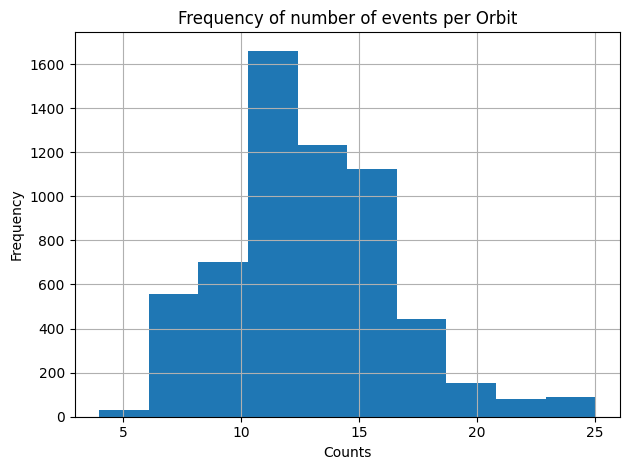

In [50]:
plt.hist(df_cut)
plt.xlabel('Counts')
plt.ylabel('Frequency')
plt.title('Frequency of number of events per Orbit')
plt.tight_layout()
plt.grid()
plt.show()

# Local track fit 

To solve the left/right ambiguity, we perform a least-square linear fit over all the possible X coordinates combinations. We consider seperately each chamber, and for each event we choose as the best track of the muon the linear fit with the smallest sum of residues, normalized to the number of degrees of freedom. This allows us to pick for each couple of X coordinates in a cell the one considered in the best fit as the actual coordinate of the recorded event. We implemented a vectorized version of the algorithm, avoiding using explicit for loops over all combinations.     

In [20]:
def fit_chamber_vectorized(df_ch):
    if len(df_ch) < 3:
        return None
    
    x_left = df_ch["X_LEFT"].values
    x_right = df_ch["X_RIGHT"].values
    z_vals = df_ch["z"].values
    N = len(x_left)

    # generate all left/right combinations (2^N x N)
    choices = np.array(list(itertools.product([0, 1], repeat=N)))
    
    # create candidate x positions for each combination  ### shape (2^N, N)
    x_matrix = np.where(choices == 0, x_left, x_right)  
    
    z_matrix = np.tile(z_vals, (2**N, 1))  # repeat y_vals for each combination

    # linear regression by hand: x = m*y + q
    z_mean = z_matrix.mean(axis=1)
    x_mean = x_matrix.mean(axis=1)
    m = np.sum((z_matrix - z_mean[:, None]) * (x_matrix - x_mean[:, None]), axis=1) / np.sum((z_matrix - z_mean[:, None])**2, axis=1)
    q = x_mean - m * z_mean
    resid = np.sum((x_matrix - (m[:, None]*z_matrix + q[:, None]))**2, axis=1)
  
    N = z_vals.shape[0]       # number of hits
    ndof = max(N-2, 1)        # degrees of freedom (avoid div by 0)
    chi_sq = resid /ndof

    best_idx = np.argmin(chi_sq)
    best = {
    "m": m[best_idx],
    "q": q[best_idx],
    "χ²/ndof": chi_sq[best_idx],
    "x_best": x_matrix[best_idx],
    "z_vals": z_vals}
    
    return best



def process_partition(df):
    results = []
    for (orbit, chamber_id), df_grp in df.groupby(["ORBIT", "CHAMBER"]):
        best = fit_chamber_vectorized(df_grp)
        if best is not None:
            results.append({
                "ORBIT": orbit,
                "CHAMBER": chamber_id,
                "m": best["m"],
                "q": best["q"],
                "χ²/ndof": best["χ²/ndof"],
                "x_best": best["x_best"],
                "z_vals": best["z_vals"]} )
            
    return pd.DataFrame(results)


 # we need to explicitly tell Dask what the output schema of the df will be

meta = pd.DataFrame({
    "ORBIT": pd.Series(dtype="int64"),
    "CHAMBER": pd.Series(dtype="int64"),
    "m": pd.Series(dtype="float64"),
    "q": pd.Series(dtype="float64"),
    "χ²/ndof": pd.Series(dtype="float64"),
    "x_best": pd.Series(dtype="object"),  
    "z_vals": pd.Series(dtype="object")
})
    

In [21]:
df_local_fit= new_df.map_partitions(process_partition,meta=meta)

In [22]:

start = time.time()

persisted = df_local_fit.persist()
wait(persisted)

end = time.time()
print(f"Persist took {end - start:.2f} seconds")

Persist took 3.75 seconds


In [23]:
%%time
# compute local fits for all orbits and all chambers 
fit_results = df_local_fit.compute()
fit_results

CPU times: user 49.2 ms, sys: 7.78 ms, total: 57 ms
Wall time: 4.95 s


,ORBIT,CHAMBER,m,q,χ²/ndof,x_best,z_vals
0,1118948,1,0.216296,-87.542832,0.775071,"[119.15484644775391, 123.14315273132324, 127.8...","[957.8, 970.8, 996.8]"
1,1118948,2,-0.267759,434.702037,0.690165,"[162.36893305969238, 152.45173388061522, 154.8...","[1016.0999999999999, 1055.1, 1042.1, 1029.1]"
2,1118948,3,-0.252889,411.517542,0.038916,"[-43.832786611938474, -53.769713388061525, -50...","[1800.3, 1839.3, 1826.3, 1813.3]"
3,1123056,0,0.130101,95.628744,0.667026,"[124.44517950744628, 121.30684726867676, 124.2...","[226.3, 200.3, 213.3, 239.3]"
4,1123056,1,0.427381,-255.825622,0.542577,"[164.47251338806151, 159.94248661193848, 152.9...","[983.8, 970.8, 957.8, 996.8]"
...,...,...,...,...,...,...,...
1755,48576415,1,-0.046563,135.055653,65.745969,"[85.46513056640624, 91.06931474609375, 80.6499...","[983.8, 957.8, 970.8, 970.8, 983.8, 996.8]"
1756,48576415,2,-0.262656,375.795920,0.086336,"[105.5649, 98.8757841796875, 101.7360579101562...","[1029.1, 1055.1, 1042.1, 1016.0999999999999]"
1757,48576415,3,-0.234706,339.878673,0.492665,"[-82.83975361328125, -87.93993056640625, -92.3...","[1800.3, 1826.3, 1839.3, 1813.3]"
1758,48580108,1,0.247827,-116.212181,13.844290,"[123.14502734375, 131.8158431640625, 121.39465...","[957.8, 996.8, 970.8]"


## Local fit plots

This process can be seen in the following example graph, where the fit is plotted for a specific event defined by the time ORBIT and chamber number. 

In [24]:
def plot_fit_chamber_hits(df_evt,orbit_id,chamber_id=3):
    # filters the selected chamber
    df_ch = df_evt[(df_evt["CHAMBER"] == chamber_id) & (df_evt["ORBIT"] == orbit_id)].compute()
    
    fig= plt.figure(figsize=(8, 6))
    
            
    plt.scatter(df_ch["x"], 
               df_ch["z"],
               color="red",label="Center")
    
    plt.scatter(df_ch["X_LEFT"], 
               df_ch["z"],
               color="blue",label="Left")
    
    plt.scatter(df_ch["X_RIGHT"], 
                df_ch["z"],
               color="green", label="Right")
    
    fit = fit_chamber_vectorized(df_ch)
    if fit is not None:
        m, q = fit["m"], fit["q"]
        z_line = np.linspace(df_ch["z"].min(), df_ch["z"].max(), 100)
        x_line = m*z_line + q
        plt.plot(x_line, z_line, color="black", linewidth=1.5,linestyle='--',label=f"Best fit (χ²/ndof = {round(fit['χ²/ndof'],2)})")

    plt.xlabel("x [mm]")
    plt.ylabel("")
    plt.title(f"Orbit: {orbit_id},Chamber {chamber_id}")
    plt.legend()
    #ax.legend()
    plt.show()

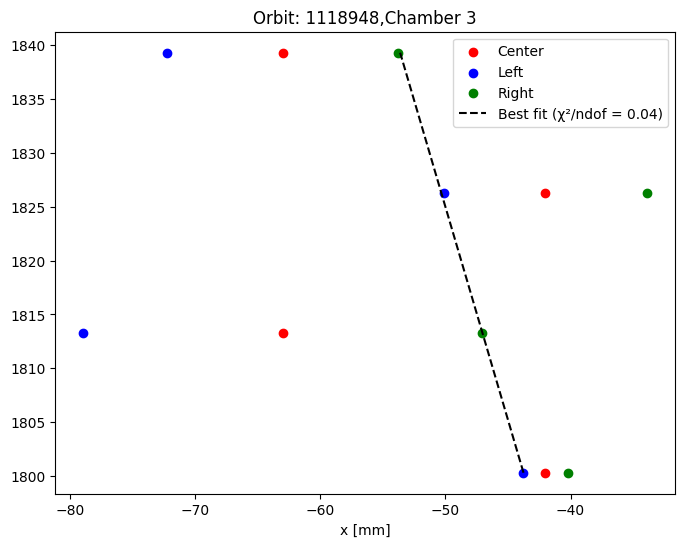

In [25]:
plot_fit_chamber_hits(new_df,orbit_id=1118948,chamber_id=3)

In [36]:

def plot_fit_chamber_hits(df_evt, orbit_id, chamber_id=3):
    # filtra la camera selezionata
    df_ch = df_evt[(df_evt["CHAMBER"] == chamber_id) & (df_evt["ORBIT"] == orbit_id)].compute()
    
    n_layers = 4
    n_cells = 16
    cell_w = 42.0  # mm
    cell_h = 13.0  # mm
    offset = cell_w / 2
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    z_min = df_ch["z"].min()-cell_h/2 ## fix the base of the grid to minimum z-half cell (to center points in the cell along z)
    
    # disegna le celle
    for layer in range(n_layers):
        x_offset = 0 if layer % 2 == 0 else -offset
        for cell in range(n_cells):
            x0 = (cell * cell_w) - (n_cells * cell_w) / 2 + cell_w/2 + x_offset ## x_offset è diverso da cell_w/2 perchè è oscillante 
            z0 = z_min + layer*cell_h  
            rect = patches.Rectangle(
                (x0, z0),
                cell_w, cell_h,
                linewidth=1, edgecolor="gray", facecolor="none"
            )
            ax.add_patch(rect)
    
    # hit
    ax.scatter(df_ch["x"], df_ch["z"], color="red", label="Center")
    ax.scatter(df_ch["X_LEFT"], df_ch["z"], color="blue", label="Left")
    ax.scatter(df_ch["X_RIGHT"], df_ch["z"], color="green", label="Right")
    
    # fit
    fit = fit_chamber_vectorized(df_ch)
    if fit is not None:
        m, q = fit["m"], fit["q"]
        z_line = np.linspace(df_ch["z"].min(), df_ch["z"].max(), 200)
        x_line = m * z_line + q
        ax.plot(x_line, z_line, color="black", linewidth=1.5,label="Best fit")
    
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("z [mm]")
    ax.set_title(f"Orbit: {orbit_id}, Chamber {chamber_id}")
    ax.legend()
    ax.set_aspect("equal")
    #ax.set_xlim(-150, 50) 
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    #plt.savefig('foo.png')
    #plt.show()
    return fig, ax

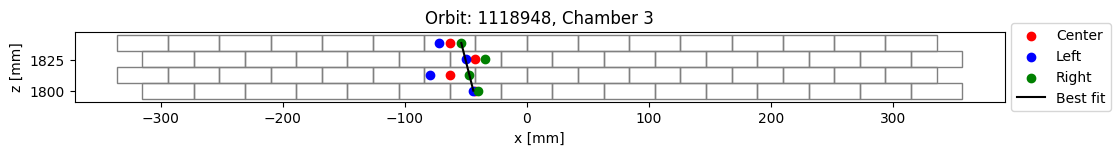

In [37]:
fig, ax = plot_fit_chamber_hits(new_df,orbit_id=1118948,chamber_id=3)
plt.show()

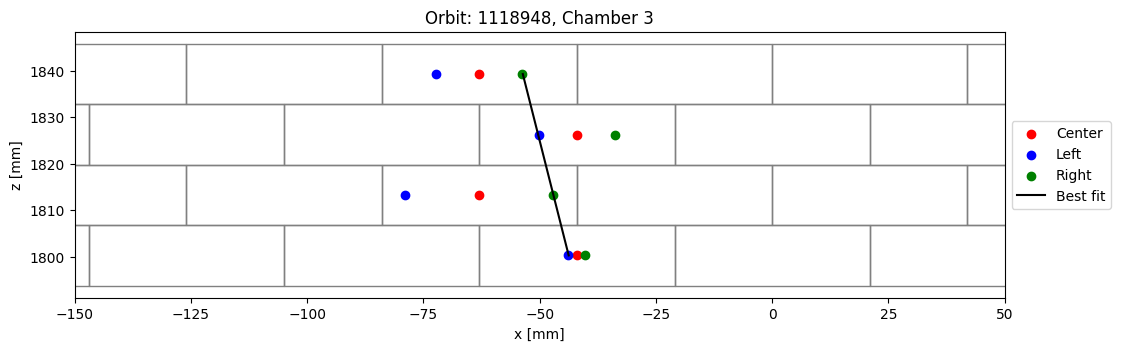

In [38]:
fig1,ax1=plot_fit_chamber_hits(new_df,orbit_id=1118948,chamber_id=3)
ax1.set_xlim(-150, 50) 
plt.show()

In [28]:
new_df[(new_df["CHAMBER"] == 3) & (new_df["ORBIT"] == 1118948)].compute()

,FPGA,CHAN,ORBIT,BX,TDC,CHAMBER,time_offset,T_HIT,t_0,T_REL,x,z,CHAN_LOCAL,layer,drift,X_RIGHT,X_LEFT
0,1,91,1118948,878,27,3,92.4,9.969829e+10,9.969829e+10,34.066666,-42.0,1800.3,27,0,1.832787,-40.167213,-43.832787
3,1,88,1118948,884,12,3,92.4,9.969829e+10,9.969829e+10,171.566666,-63.0,1839.3,24,3,9.230287,-53.769713,-72.230287
5,1,90,1118948,883,17,3,92.4,9.969829e+10,9.969829e+10,150.733337,-42.0,1826.3,26,2,8.109454,-33.890546,-50.109454
7,1,89,1118948,889,12,3,92.4,9.969829e+10,9.969829e+10,296.566666,-63.0,1813.3,25,1,15.955287,-47.044713,-78.955287


In [29]:
fit_results[(fit_results["CHAMBER"] == 3) & (fit_results["ORBIT"] == 1118948)]

,ORBIT,CHAMBER,m,q,χ²/ndof,x_best,z_vals
2,1118948,3,-0.252889,411.517542,0.038916,"[-43.832786611938474, -53.769713388061525, -50...","[1800.3, 1839.3, 1826.3, 1813.3]"


# Global fit

Similarly, a global linear fit considering the chambers 0,2 and 3 was performed to track the whole trajectory of the muon inside the detector.
In the following graphs, the results are presented on scale relative to the geometry of the detector



In [30]:
def fit_global(df_orbit):
    """
    df_orbit: DataFrame with local fit results for chambers 0,2,3
              and a single ORBIT.
              It needs to contain columns 'CHAMBER', 'x_best', 'z_vals'. """
    # Consider only chambers 0,2,3
    df_sel = df_orbit[df_orbit["CHAMBER"].isin([0,2,3])]
    if len(df_sel) < 2:
        return None  # troppo poche camere per un fit globale

    # Concatenate all x_best e z_vals of 
    x_all = np.concatenate(df_sel["x_best"].values)
    z_all = np.concatenate(df_sel["z_vals"].values)
    
    # Global linear fit (least squares)
    z_mean = np.mean(z_all)
    x_mean = np.mean(x_all)
    
    m = np.sum((z_all - z_mean)*(x_all - x_mean))/np.sum((z_all - z_mean)**2)
    q = x_mean - m*z_mean
    
    resid = np.sum((x_all - (m*z_all + q))**2)
    ndof = len(x_all)-2
    chi_sq = resid / ndof
    
    return {
        "m_global": m,
        "q_global": q,
        "χ²/ndof_global": chi_sq,
        "x_all": x_all,
        "z_all": z_all
    }

def process_partition_global(df_fit_local):
    results = []
    for orbit, df_grp in df_fit_local.groupby("ORBIT"):
        df_pass = df_grp[["CHAMBER", "x_best", "z_vals"]]
        best_global = fit_global(df_pass)
        if best_global is not None:
            results.append({
                "ORBIT": orbit,
                **best_global })
    return pd.DataFrame(results)

# Schema Dask per il fit globale
meta_global = pd.DataFrame({
    "ORBIT": pd.Series(dtype="int64"),
    "m_global": pd.Series(dtype="float64"),
    "q_global": pd.Series(dtype="float64"),
    "χ²/ndof_global": pd.Series(dtype="float64"),
    "x_all": pd.Series(dtype="object"),
    "z_all": pd.Series(dtype="object")
})


In [31]:
df_global_fit= df_local_fit.map_partitions(process_partition_global,meta=meta_global)

In [32]:
start = time.time()

persisted = df_global_fit.persist()
wait(persisted)   ### ensures computation finishes

end = time.time()
print(f"Persist took {end - start:.2f} seconds")


Persist took 6.29 seconds


In [33]:
%%time
# global fit for all orbits
global_fit_results = df_global_fit.compute()
global_fit_results

CPU times: user 29.1 ms, sys: 4.31 ms, total: 33.4 ms
Wall time: 6.48 s


,ORBIT,m_global,q_global,χ²/ndof_global,x_all,z_all
0,1118948,-0.262812,429.576638,0.260344,"[162.36893305969238, 152.45173388061522, 154.8...","[1016.0999999999999, 1055.1, 1042.1, 1029.1, 1..."
1,1123056,0.077788,107.109373,0.759312,"[124.44517950744628, 121.30684726867676, 124.2...","[226.3, 200.3, 213.3, 239.3, 1055.1, 1029.1, 1..."
2,1124284,-0.057558,148.519193,0.313131,"[89.00340082092285, 90.70706694030761, 87.4432...","[1042.1, 1016.0999999999999, 1055.1, 1029.1, 1..."
3,1126947,0.091026,21.586312,0.521112,"[115.42823305969239, 116.2891, 118.2079, 113.5...","[1029.1, 1042.1, 1055.1, 1016.0999999999999, 1..."
4,1130581,0.199468,-45.754901,102.047356,"[167.7041, 151.55506694030763, 162.3241, 160.8...","[1042.1, 1029.1, 1016.0999999999999, 1055.1, 1..."
...,...,...,...,...,...,...
444,48559795,0.099982,30.982830,2.039502,"[50.9971568359375, 53.15100107421875, 53.91131...","[200.3, 239.3, 226.3, 213.3, 1042.1, 1016.0999..."
445,48560150,0.212607,-54.569361,415.031614,"[-29.1901568359375, -13.25631474609375, 18.950...","[239.3, 226.3, 200.3, 1016.0999999999999, 1029..."
446,48569403,0.310180,-156.300971,0.540399,"[-86.227341015625, -94.3421568359375, -90.2193...","[226.3, 200.3, 213.3, 239.3, 1042.1, 1016.0999..."
447,48570850,0.230943,-64.775562,1.389592,"[-12.8976568359375, -8.55068525390625, -19.129...","[226.3, 239.3, 200.3, 1016.0999999999999, 1042..."


## Global fit plots

In [34]:


def plot_fit_global_hits_with_detector(df_evt, orbit_id):
    # Filtra l'orbit scelto
    df_ch = df_evt[df_evt["ORBIT"] == orbit_id].compute()
    if df_ch.empty:
        print(f"No global fit found for ORBIT={orbit_id}")
        return
    
    # Prendo la prima (e unica) riga
    row = df_ch.iloc[0]
    m, q = row["m_global"], row["q_global"]
    z_all, x_all = row["z_all"], row["x_all"]   # array numpy
    chi_sq= row["χ²/ndof_global"]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Parametri geometrici reali del rivelatore
    shift_chamber = {
        0: {'x': 0, 'y': 0, 'z': 219.8},  # Ch 0
        1: {'x': 0, 'y': 0, 'z': 977.3},  # Ch 1
        2: {'x': 0, 'y': 0, 'z': 1035.6}, # Ch 2
        3: {'x': 0, 'y': 0, 'z': 1819.8}, # Ch 3
    }
    
    # Parametri geometrici
    n_layers = 4
    n_cells = 16
    n_chambers = 4 
    cell_w = 42.0  # mm
    cell_h = 13.0  # mm
    offset = cell_w / 2
    
    # Dimensioni totali delle camere
    chamber_width = n_cells * cell_w  # 16 * 42 = 672 mm
    chamber_height = n_layers * cell_h  # 4 * 13 = 52 mm
    
    # Disegna le camere del rivelatore
    #colors = ['lightgray', 'lightblue', 'lightgreen', 'lightyellow']
    
    z_min = z_all.min() - cell_h/2  # ancora la base della griglia al minimo z-metà cella
    
    for chamber in range(n_chambers):  
        ch_name = f'Ch {chamber}'
        z_pos = shift_chamber[chamber]['z']

        if ch_name == 'Ch 1':
            ## Rettangolo della camera 1
            chamber = patches.Rectangle(
                (-chamber_width/2, z_pos - chamber_height/2),
                chamber_width+cell_w/2, chamber_height,
                linewidth=1, edgecolor='black', facecolor='none'
            )
            ax.add_patch(chamber)
            
            # Numero di linee orizzontali
            num_lines = 4
            y_positions = np.linspace(z_pos - chamber_height/2, z_pos + chamber_height/2, num_lines+2)[1:-1]
            
            for y in y_positions:
                ax.hlines(y, -chamber_width/2, chamber_width/2+cell_w/2, colors='grey', linewidth=0.8)
        else:
            # Griglia delle celle usando il pattern specificato
            for layer in range(n_layers):
                x_offset = 0 if layer % 2 == 0 else -offset
                for cell in range(n_cells):
                    x0 = (cell * cell_w) - (n_cells * cell_w) / 2 + cell_w/2 + x_offset
                    z0 = (z_pos + layer * cell_h)-chamber_height/2
                    rect = patches.Rectangle(
                        (x0, z0),
                        cell_w, cell_h,
                        linewidth=1, edgecolor="gray", facecolor="none"
                    )
                    ax.add_patch(rect)
        
        # Etichetta della camera
        ax.text(-chamber_width/2 - 30, z_pos, ch_name, 
                horizontalalignment='center', fontsize=10, fontweight='bold')
        
    
    # Scatter delle hit (sovrapposto alle camere)
    ax.scatter(x_all, z_all, color="red", s=50, zorder=10, 
               label="Hits", edgecolors='darkred', linewidth=1)
    
    # Retta del fit globale
    z_line = np.linspace(z_all.min() - 50, z_all.max() + 50, 100)
    x_line = m * z_line + q
    ax.plot(x_line, z_line, color="red", linewidth=2, 
            label=f"Fit globale (χ²/dof={round(chi_sq,2)})", zorder=9, linestyle='--')
    
    # Miglioramenti estetici
    ax.set_xlabel("x [mm]", fontsize=12)
    ax.set_ylabel("z [mm]", fontsize=12)
    ax.set_title(f"Globale track Fit - Orbit: {orbit_id}", fontsize=14, fontweight='bold')
    ax.legend(loc='best', bbox_to_anchor=(0.95, 0.9))
    #ax.grid(True, alpha=0.3)
    
    # Imposta i limiti degli assi
    z_min = min([shift_chamber[i]['z'] for i in range(4)]) - 100
    z_max = max([shift_chamber[i]['z'] for i in range(4)]) + 100
    ax.set_xlim(-chamber_width/2 - 50, chamber_width/2 + 50)
    ax.set_ylim(z_min, z_max)
    
    #ax.set_xlim(190,250)
    #ax.set_ylim(1790,1870)

    plt.tight_layout()
    plt.show()


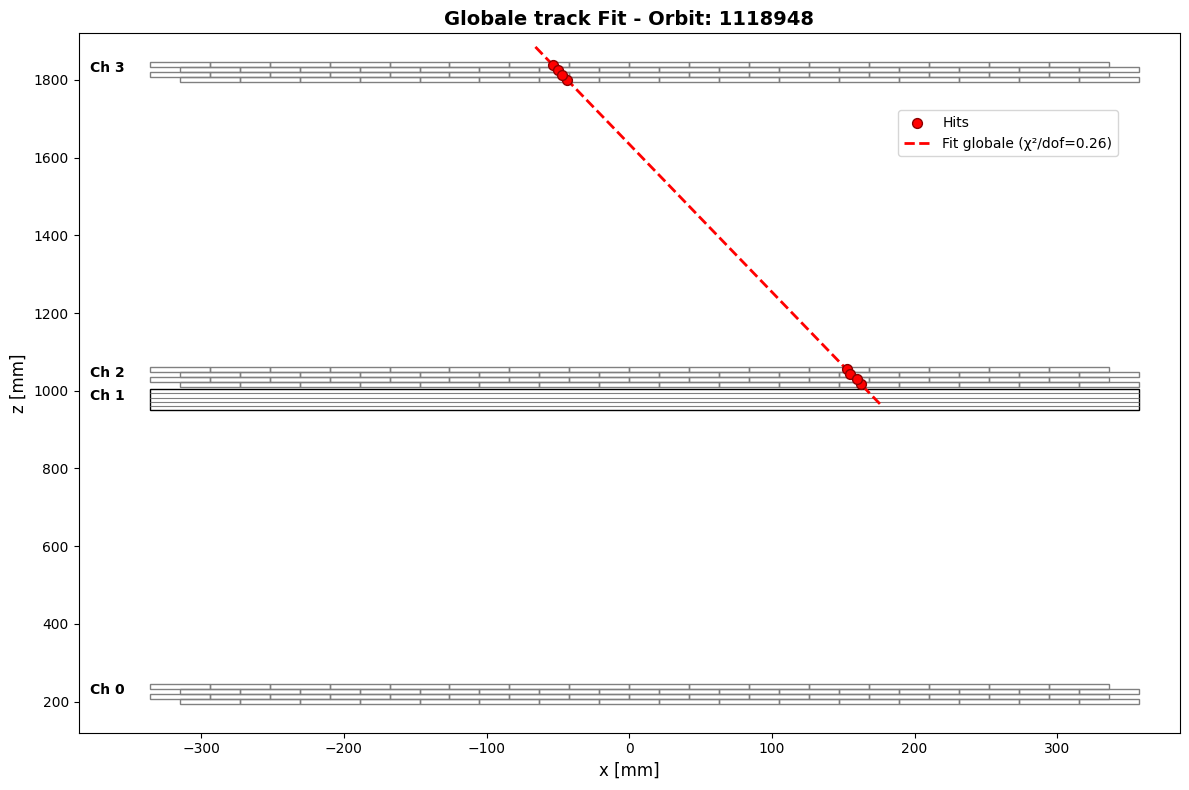

In [35]:
plot_fit_global_hits_with_detector(df_global_fit,orbit_id=1118948)

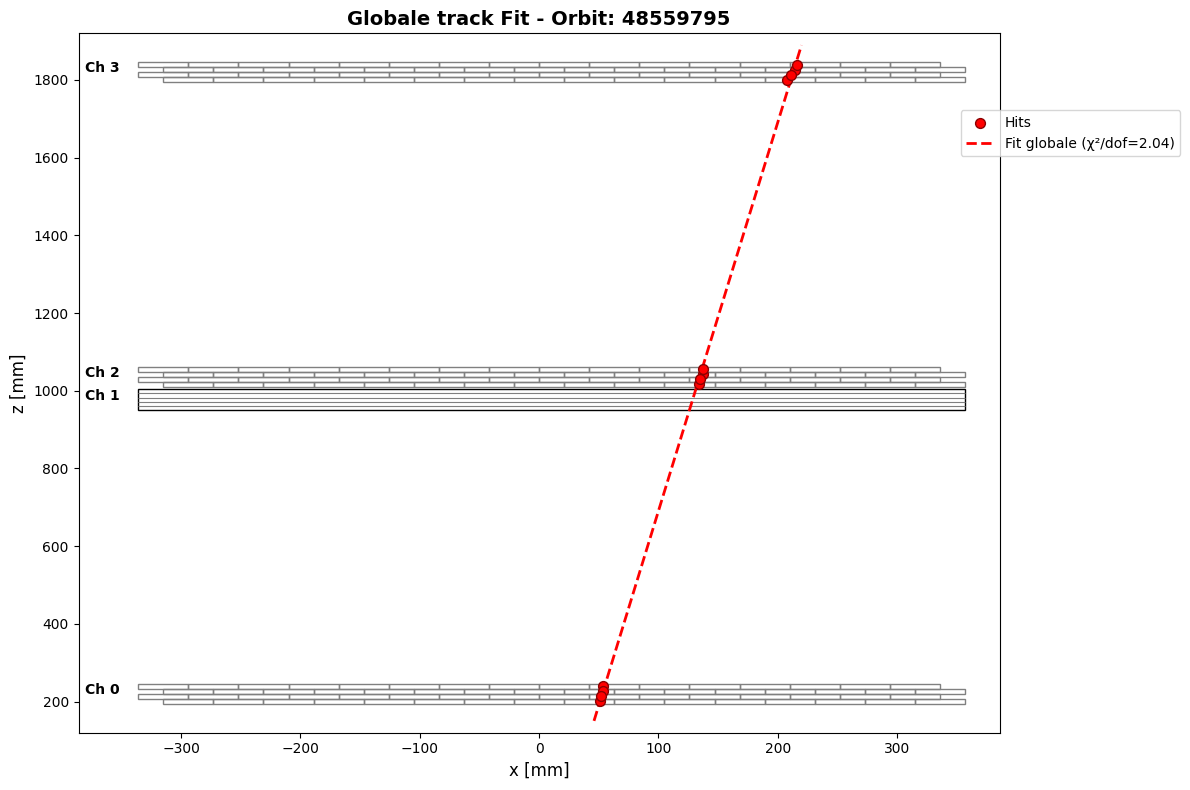

In [36]:
plot_fit_global_hits_with_detector(df_global_fit,orbit_id=48559795)

Some orbits appear to be clealry problematic (very high $\chi^2$): these signals could be uncorrelated background noise or signals from two different muons crossing the chambers in the same orbit.     

Let's examine some of these events with a high reduced $\chi^2$.

In [37]:
bad_global_fit_results = global_fit_results[global_fit_results['χ²/ndof_global']>2.8] # 2.8 defines a 4sigma deviation form expected value of 1
bad_global_fit_results

,ORBIT,m_global,q_global,χ²/ndof_global,x_all,z_all
4,1130581,0.199468,-45.754901,102.047356,"[167.7041, 151.55506694030763, 162.3241, 160.8...","[1042.1, 1029.1, 1016.0999999999999, 1055.1, 1..."
12,1219964,0.174370,-94.268712,127.568919,"[-56.24451420898438, -60.23468032836914, -65.5...","[239.3, 213.3, 200.3, 226.3, 200.3, 1042.1, 10..."
13,1248672,0.129565,50.958037,16.619795,"[80.74151420898437, 76.4356535522461, 79.84298...","[200.3, 239.3, 213.3, 1029.1, 1055.1, 1042.1, ..."
16,1273848,-0.046760,180.600790,4.091249,"[128.62723470153807, 135.75573388061522, 131.2...","[1042.1, 1016.0999999999999, 1055.1, 1029.1, 1..."
18,1326563,0.175498,3.893141,10.668606,"[44.989485791015625, 44.36181967163086, 46.157...","[226.3, 200.3, 239.3, 1055.1, 1016.09999999999..."
...,...,...,...,...,...,...
436,48501862,-0.185989,320.560495,3.251188,"[277.42413056640623, 282.6696305664062, 279.08...","[239.3, 213.3, 226.3, 1042.1, 1016.09999999999..."
439,48534261,0.313925,-208.458512,3.001761,"[-142.88968525390624, -135.0887115234375, -134...","[213.3, 239.3, 226.3, 1042.1, 1029.1, 1016.099..."
441,48545828,-0.137757,293.754482,677.501221,"[238.74181474609375, 310.39652734375, 222.3148...","[213.3, 213.3, 226.3, 226.3, 239.3, 239.3, 226..."
442,48547426,0.079711,86.612220,431.361893,"[165.86588955078125, 130.77924208984376, 172.1...","[1016.0999999999999, 1016.0999999999999, 1042...."


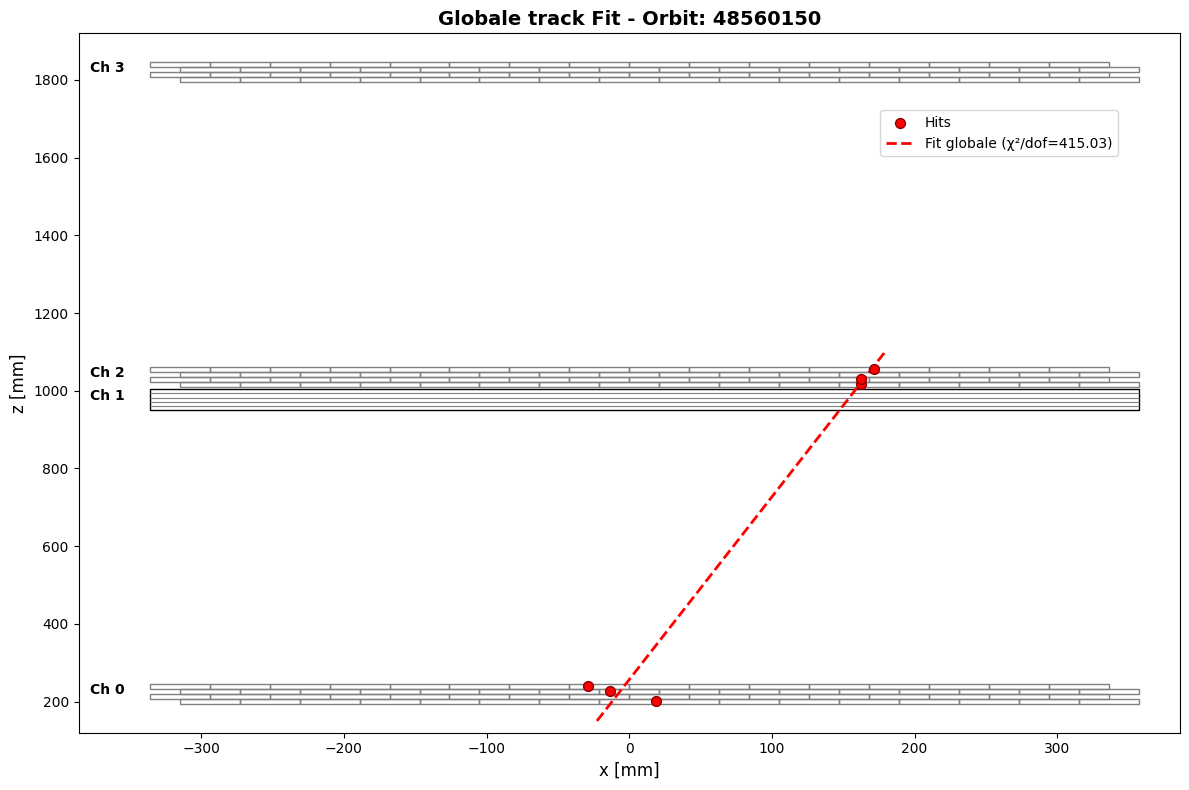

In [38]:
plot_fit_global_hits_with_detector(df_global_fit,orbit_id=48560150)

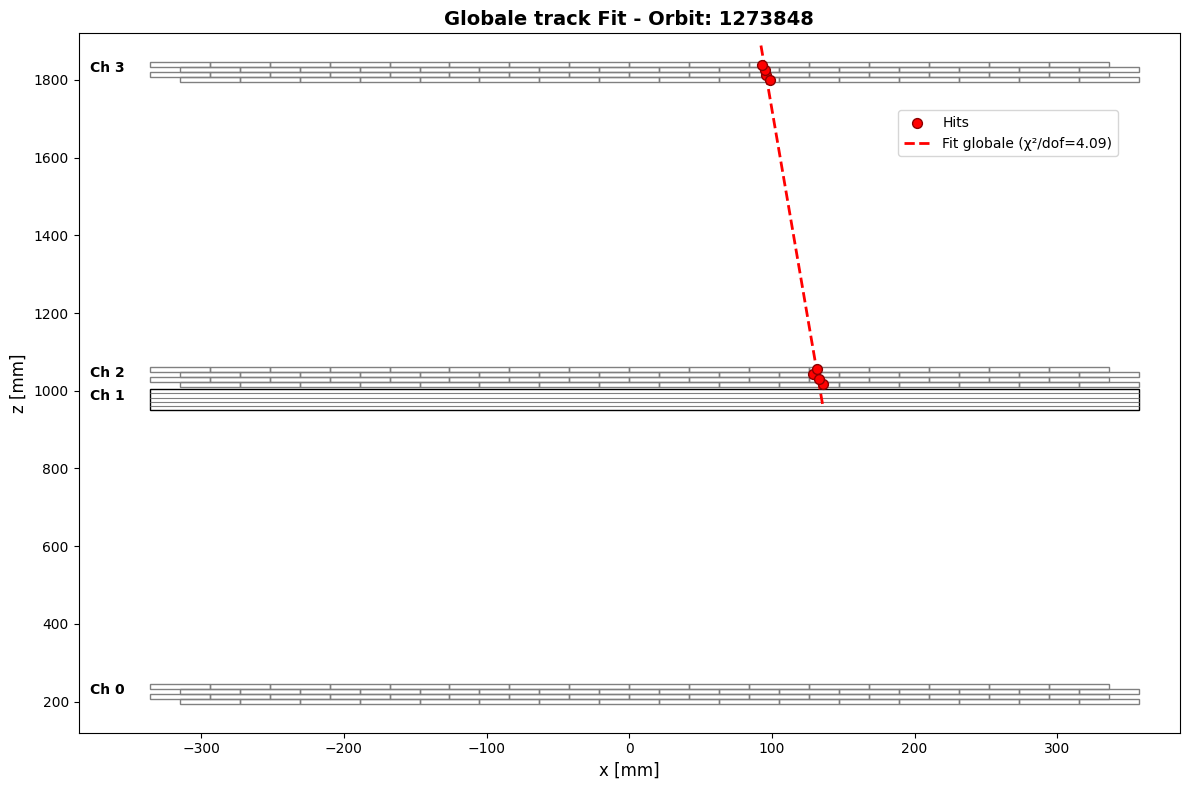

In [39]:
plot_fit_global_hits_with_detector(df_global_fit,orbit_id=1273848)

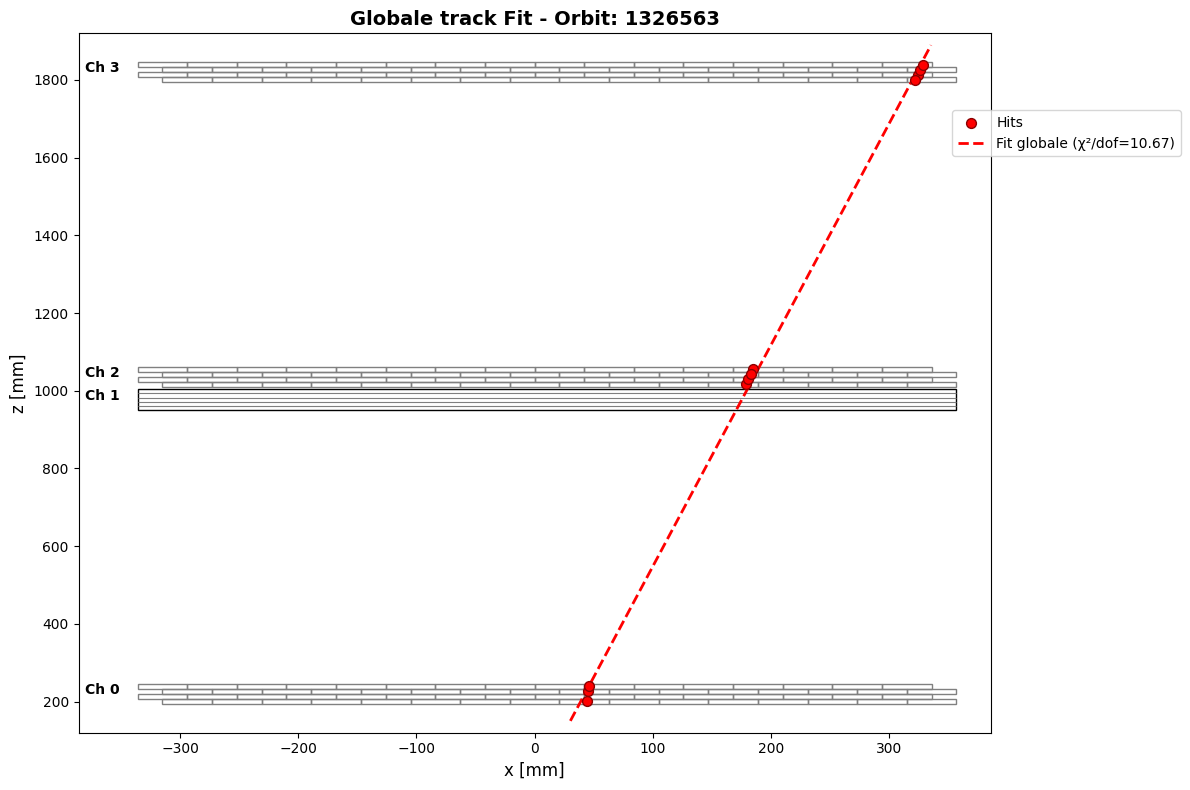

In [40]:
plot_fit_global_hits_with_detector(df_global_fit,orbit_id=1326563)

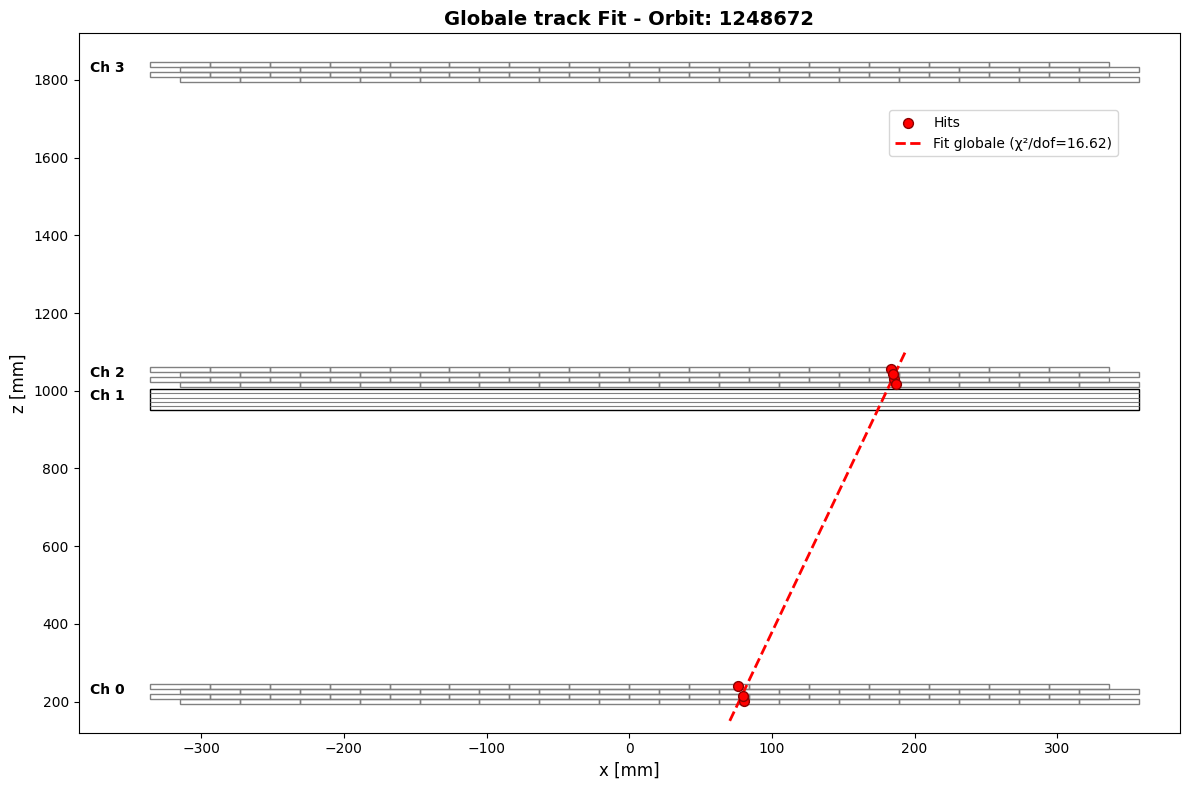

In [41]:
plot_fit_global_hits_with_detector(df_global_fit,orbit_id=1248672)

# Single detector angular resolution

We compute the angular difference between the global track fit and the locaal track fit of Chamber 2, considering only events with a resonable $\chi^2$ value (discarding probable noise and errors in the track computation). The mean value of the absolute angular differences across all events gives an estimate of the detector angular resolution. 

The reduced $\chi^2$ with N degrees of freedom has an expected value of 1, with standard deviation $\sigma=\sqrt{2/N}$. Considering in our case we have at most N=10, then $\sigma \approx 0.45$. We have around 4600 reconstruceted events (orbits), therefore we are not expecting any event with a reduced $\chi^2$ more than 4$\sigma\approx 1.8$ away from unity. We consider these events as errors and discard them in the angular resolution estimate.  

In [42]:
fit_results_2 = fit_results[fit_results['CHAMBER']==2]

# merge the local and global fit results on common orbits
merged = fit_results_2.merge(
    global_fit_results,
    on="ORBIT",
    how="inner")

compare_results = merged[merged['χ²/ndof_global'] < 2.8]


ang_diff = compare_results.copy()
ang_diff['ang_diff'] = np.degrees(np.arctan((ang_diff["m"] - ang_diff["m_global"])))
ang_diff= ang_diff[['ORBIT','χ²/ndof_global','m','m_global','ang_diff']]
ang_diff

,ORBIT,χ²/ndof_global,m,m_global,ang_diff
0,1118948,0.260344,-0.267759,-0.262812,-0.283492
1,1123056,0.759312,0.094841,0.077788,0.976981
2,1124284,0.313131,-0.071249,-0.057558,-0.784409
3,1126947,0.521112,0.114014,0.091026,1.316880
5,1135298,0.165135,0.336941,0.337672,-0.041869
...,...,...,...,...,...
4575,48558325,0.192869,-0.146571,-0.142676,-0.223151
4576,48559795,2.039502,0.092908,0.099982,-0.405311
4578,48569403,0.540399,0.362600,0.310180,3.000686
4579,48570850,1.389592,0.162918,0.230943,-3.891522


In [43]:
ang_res = np.abs(ang_diff['ang_diff']).mean()
err = ang_diff['ang_diff'].std()/len(ang_diff)**0.5
print(f"Our estimate for the angular resolution of the single detector is {ang_res:.2f}° +- {err:.2f}°")

Our estimate for the angular resolution of the single detector is 1.04° +- 0.03°


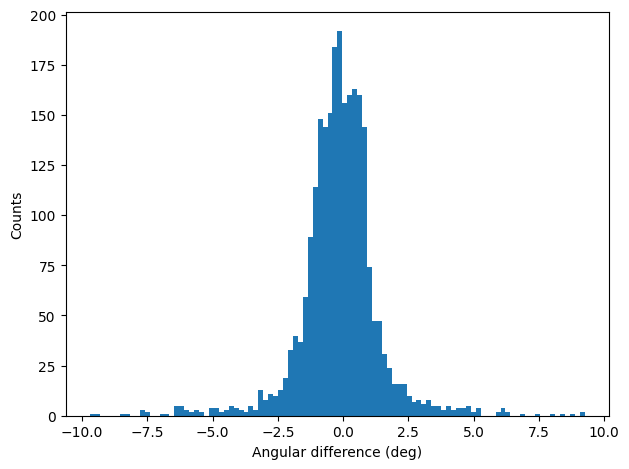

In [44]:
plt.hist(ang_diff['ang_diff'],bins=100)
plt.xlabel('Angular difference (deg)')
plt.ylabel('Counts')
plt.tight_layout()
plt.show()

In [45]:
client.close()